In [34]:
import joblib

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression

In [36]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

The `process()` function takes:

- `path` → path to the crop dataset CSV file
- `s` → user-provided input values in this order:
  `N, P, K, temperature, humidity, ph, rainfall`

Steps performed:

1. Load the crop dataset.
2. Separate the 7 input features from the crop label.
3. Convert the user's input into a 2D NumPy array.
4. Standardize the dataset using `StandardScaler`.
5. Train a linear SVM model.
6. Predict the crop for the user's input using SVM.
7. Train a Logistic Regression model.
8. Predict the crop using Logistic Regression.
9. Return both predictions.


In [48]:
def predict_crop(path, s):
    df = pd.read_csv('Crop_recommendation.csv')
    x1 = df[FEATURES].values
    y1 = df['label'].values
    
# Convert the user's input into a 2D NumPy array
    x = np.asarray(s).reshape(1, -1)
# Standardize the feature values
    scaler = StandardScaler()
    x1_scaled = scaler.fit_transform(x1)
    x_scaled = scaler.transform(x)

    # SVM MODEL

    model2 = svm.SVC(kernel='linear')
    model2.fit(x1_scaled, y1)
    svm_pred = model2.predict(x_scaled)

    # LOGISTIC REGRESSION MODEL
next we have svm impleme
    model2 = LogisticRegression(max_iter=1000)
    model2.fit(x1_scaled, y1)
    lr_pred = model2.predict(x_scaled)

    return svm_pred, lr_pred

In [49]:
    sample_input = [90, 42, 43, 20.87, 82.00, 6.5, 202.9]
    svm_result, lr_result = process("Crop_recommendation.csv", sample_input)
    print(f"SVM recommendation: {svm_result}")
    print(f"Logistic Regression recommendation: {lr_result}")

SVM recommendation: ['rice']
Logistic Regression recommendation: ['rice']


# SVM

In [38]:
import os
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import svm

In [39]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

## SVM MODEL - TRAINING AND EVALUATION

This function:
 1. Loads the crop dataset
 2. Separates features (X) and target label (y)
 3. Splits the data into training and testing sets
 4. Standardizes the feature values
 5. Trains a Linear SVM classifier
 6. Saves the trained SVM model and scaler
 7. Predicts crop labels for the test data
 8. Calculates model performance metrics
 9. Saves predictions and metrics into the results folder

In [50]:
def train_svm(path):
    # # Create the results folder if it does not already exist
    os.makedirs('results', exist_ok=True)   

    df = pd.read_csv(path)
    x1 = df[FEATURES].values
    y1 = df['label'].values

    #Train Test Split
    class_counts = Counter(y1)
    can_stratify = min(class_counts.values()) >= 2
    X_train, X_test, y_train, y_test = train_test_split(
        x1, y1, test_size=0.2, random_state=42, stratify=y1 if can_stratify else None
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model2 = svm.SVC(kernel='linear')
    model2.fit(X_train_scaled, y_train)
# Save the trained SVM model and scaler
# These files are later used by the Tkinter GUI
    joblib.dump(model2, "svm_model.pkl")
    joblib.dump(scaler, "scaler.pkl")
  # Make predictions on the test data
    y_pred = model2.predict(X_test_scaled)
#save predictions
    with open("results/resultSVM.csv", "w") as result2:
        result2.write("ID,Predicted Value\n")
        for j in range(len(y_pred)):
            result2.write(str(j+1) + "," + str(y_pred[j]) + "\n")
#model evalution
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
#display evalution results
    print("---------------------------------------------------------")
    print("ACCURACY VALUE FOR SVM IS %f " % acc)
    print("PRECISION VALUE FOR SVM IS %f " % prec)
    print("RECALL VALUE FOR SVM IS %f " % rec)
    print("F1-SCORE VALUE FOR SVM IS %f " % f1)
    print("---------------------------------------------------------")
#Save evalution metrics
    with open('results/SVMMetrics.csv', 'w') as result2:
        result2.write("Parameter,Value\n")
        result2.write(f"ACCURACY,{acc}\n")
        result2.write(f"PRECISION,{prec}\n")
        result2.write(f"RECALL,{rec}\n")
        result2.write(f"F1-SCORE,{f1}\n")

    return acc, prec, rec, f1


In [52]:
acc, prec, rec, svm_f1 = train_svm('Crop_recommendation.csv')

---------------------------------------------------------
ACCURACY VALUE FOR SVM IS 0.981818 
PRECISION VALUE FOR SVM IS 0.983747 
RECALL VALUE FOR SVM IS 0.981818 
F1-SCORE VALUE FOR SVM IS 0.981715 
---------------------------------------------------------


# Logistic Regression

In [42]:
import os
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

## LOGISTIC REGRESSION - TRAINING AND EVALUATION

## This function:
 1. Loads the crop dataset
 2. Separates features (X) and target label (y)
 3. Splits the data into training and testing sets
 4. Standardizes the feature values
 5. Trains a Logistic Regression classifier
 6. Saves the trained Logistic Regression model
 7. Predicts crop labels for the test data
 8. Calculates model performance metrics
 9. Saves predictions and metrics into the results folder

In [60]:
def train_lr(path):
    os.makedirs('results', exist_ok=True)

    df = pd.read_csv(path)

    x1 = df[FEATURES].values
    y1 = df['label'].values

    class_counts = Counter(y1)
    can_stratify = min(class_counts.values()) >= 2

    X_train, X_test, y_train, y_test = train_test_split(
        x1,
        y1,
        test_size=0.2,
        random_state=42,
        stratify=y1 if can_stratify else None
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model2 = LogisticRegression(max_iter=1000)

    model2.fit(X_train_scaled, y_train)

    joblib.dump(model2, "lr_model.pkl")

    y_pred = model2.predict(X_test_scaled)

    with open("results/resultRegression.csv", "w") as result2:
        result2.write("ID,Predicted Value\n")

        for j in range(len(y_pred)):
            result2.write(str(j + 1) + "," + str(y_pred[j]) + "\n")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )
    rec = recall_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )

    print("---------------------------------------------------------")
    print("ACCURACY VALUE FOR Logistic Regression IS %f " % acc)
    print("PRECISION VALUE FOR Logistic Regression IS %f " % prec)
    print("RECALL VALUE FOR Logistic Regression IS %f " % rec)
    print("F1-SCORE VALUE FOR Logistic Regression IS %f " % f1)
    print("---------------------------------------------------------")

    with open('results/RegressionMetrics.csv', 'w') as result2:
        result2.write("Parameter,Value\n")
        result2.write(f"ACCURACY,{acc}\n")
        result2.write(f"PRECISION,{prec}\n")
        result2.write(f"RECALL,{rec}\n")
        result2.write(f"F1-SCORE,{f1}\n")

    return acc, prec, rec, f1,y_test,y_pred

In [62]:
acc, prec, rec, f1,y_test,y_pred = train_lr("Crop_recommendation.csv")

---------------------------------------------------------
ACCURACY VALUE FOR Logistic Regression IS 0.972727 
PRECISION VALUE FOR Logistic Regression IS 0.974022 
RECALL VALUE FOR Logistic Regression IS 0.972727 
F1-SCORE VALUE FOR Logistic Regression IS 0.972464 
---------------------------------------------------------


In [24]:
import joblib

svm_model = joblib.load("svm_model.pkl")
lr_model = joblib.load("lr_model.pkl")
scaler = joblib.load("scaler.pkl")

In [25]:
from sklearn.neural_network import MLPClassifier

In [30]:
def evaluate_neural_network(path):

    df = pd.read_csv(path)

    x1 = df[FEATURES].values
    y1 = df['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        x1,
        y1,
        test_size=0.2,
        random_state=42,
        stratify=y1
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=1000,
        random_state=42
    )

    # model.fit(X_train_scaled, y_train)

    # y_pred = model.predict(X_test_scaled)
    model.fit(X_train_scaled, y_train)

    # Training prediction
    train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    
    # Test prediction
    y_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    
    print("Training Accuracy:", train_acc)
    print("Testing Accuracy:", test_acc)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )
    rec = recall_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred,
        average='weighted',
        zero_division=0
    )

    print("---------------------------------------------")
    print("ACCURACY VALUE FOR NEURAL NETWORK IS %f" % acc)
    print("PRECISION VALUE FOR NEURAL NETWORK IS %f" % prec)
    print("RECALL VALUE FOR NEURAL NETWORK IS %f" % rec)
    print("F1-SCORE VALUE FOR NEURAL NETWORK IS %f" % f1)
    print("---------------------------------------------")

    return acc, prec, rec, f1

In [31]:
nn_acc, nn_prec, nn_rec, nn_f1 = evaluate_neural_network(
    "Crop_recommendation.csv"
)

Training Accuracy: 0.9965909090909091
Testing Accuracy: 0.9931818181818182
---------------------------------------------
ACCURACY VALUE FOR NEURAL NETWORK IS 0.993182
PRECISION VALUE FOR NEURAL NETWORK IS 0.993290
RECALL VALUE FOR NEURAL NETWORK IS 0.993182
F1-SCORE VALUE FOR NEURAL NETWORK IS 0.993180
---------------------------------------------


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [64]:
import matplotlib.pyplot as plt

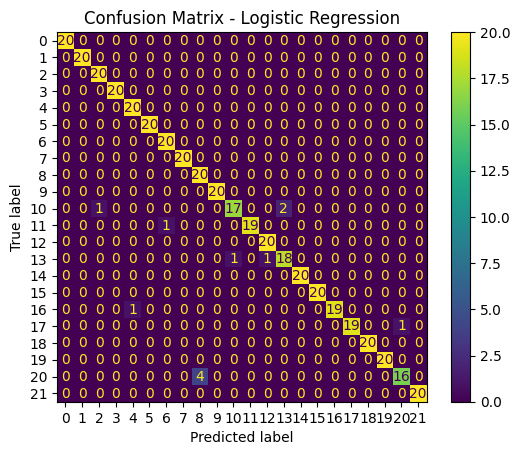

In [65]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

| Model                   |   Accuracy |
| ----------------------- | ---------: |
| **Logistic Regression** | **97.27%** |
| **SVM (Linear)**        | **98.18%** |
| **Neural Network**      | **99.32%** |
